# Lab 03: Intuicion Estadistica - Parte 1

Sistema sintetico para estudiar la frontera de fase entre sesgo y varianza en un problema binario unidimensional.

## Vibe Coding Disclaimer

Este cuaderno fue construido con asistencia de IA bajo supervision humana. Todos los supuestos, ecuaciones y resultados se verifican explicitamente durante la ejecucion del laboratorio.

> 1. 'Generar dos distribuciones de probabilidad centradas en 5.0, 7.5 con desviacion estandar de 2.5 y 1.5 respectivamente. Realizar un grafico de ambas distribuciones de probabilidad.'

Modelamos ambos estados con gaussianas:

$$
p(x\mid\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

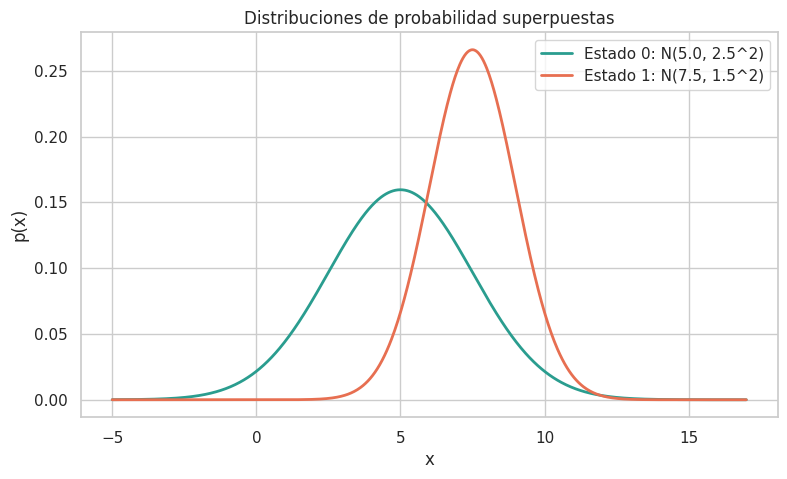

In [51]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.dynamics as dynamics_module
import src.visuals as visuals_module

importlib.reload(dynamics_module)
importlib.reload(visuals_module)

LearningTheoryEngine = dynamics_module.LearningTheoryEngine
plot_overlapping_pdfs_and_histograms = visuals_module.plot_overlapping_pdfs_and_histograms
set_style = visuals_module.set_style

set_style()
engine = LearningTheoryEngine(mu1=5.0, sigma1=2.5, mu2=7.5, sigma2=1.5)
params = engine.get_gaussian_parameters()

x_grid = np.linspace(-5.0, 17.0, 800)
pdf_0 = norm.pdf(x_grid, loc=params['mu1'], scale=params['sigma1'])
pdf_1 = norm.pdf(x_grid, loc=params['mu2'], scale=params['sigma2'])

plt.figure(figsize=(9, 5))
plt.plot(x_grid, pdf_0, lw=2, color='#2a9d8f', label='Estado 0: N(5.0, 2.5^2)')
plt.plot(x_grid, pdf_1, lw=2, color='#e76f51', label='Estado 1: N(7.5, 1.5^2)')
plt.title('Distribuciones de probabilidad superpuestas')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

> 2. '¿Que frontera analitica puede separar los datos? Determine una expresion analitica en este caso.'

La frontera de fase $x^*$ se obtiene imponiendo degeneracion de verosimilitudes:

$$
p(x\mid\mu_1,\sigma_1)=p(x\mid\mu_2,\sigma_2).
$$

Al tomar logaritmos y reordenar, surge una cuadratica:

$$
a x^2 + b x + c = 0,
$$

con

$$
a=\frac{1}{\sigma_1^2}-\frac{1}{\sigma_2^2},\quad
b=-\frac{2\mu_1}{\sigma_1^2}+\frac{2\mu_2}{\sigma_2^2},\quad
c=\frac{\mu_1^2}{\sigma_1^2}-\frac{\mu_2^2}{\sigma_2^2}+2\ln\left(\frac{\sigma_1}{\sigma_2}\right).
$$

La raiz fisicamente relevante se toma como la ubicada entre ambas medias (o la mas cercana al punto medio si no cae en ese intervalo).

In [52]:
boundary_report = engine.analytical_boundary()
print(f"Frontera analitica calculada en x* = {boundary_report['boundary']:.4f}")
print(f"Raices encontradas: {boundary_report['roots']}")

Frontera analitica calculada en x* = 5.8921
Raices encontradas: [5.892132097593953, 11.92036790240605]


> 3. 'Empleando el metodo Random variates (rvs), genere 100 muestras aleatorias para cada distribucion; estos seran los datos de entrenamiento.'

In [53]:
samples_state_0, samples_state_1 = engine.generate_training_samples(n_samples=100, random_state=2026)
print(f"Muestras generadas: {len(samples_state_0)} para Estado 0, {len(samples_state_1)} para Estado 1.")

Muestras generadas: 100 para Estado 0, 100 para Estado 1.


> 4. 'Realice un grafico en el que pueda superponer ambas distribuciones; estas 200 muestras seran las caracteristicas (features) de nuestro data frame. Para cada caracteristica tendremos una etiqueta (labels) correspondiente a 0 o 1.'

La linea vertical punteada representa la frontera de fase $x^*$, donde ambas verosimilitudes son degeneradas.

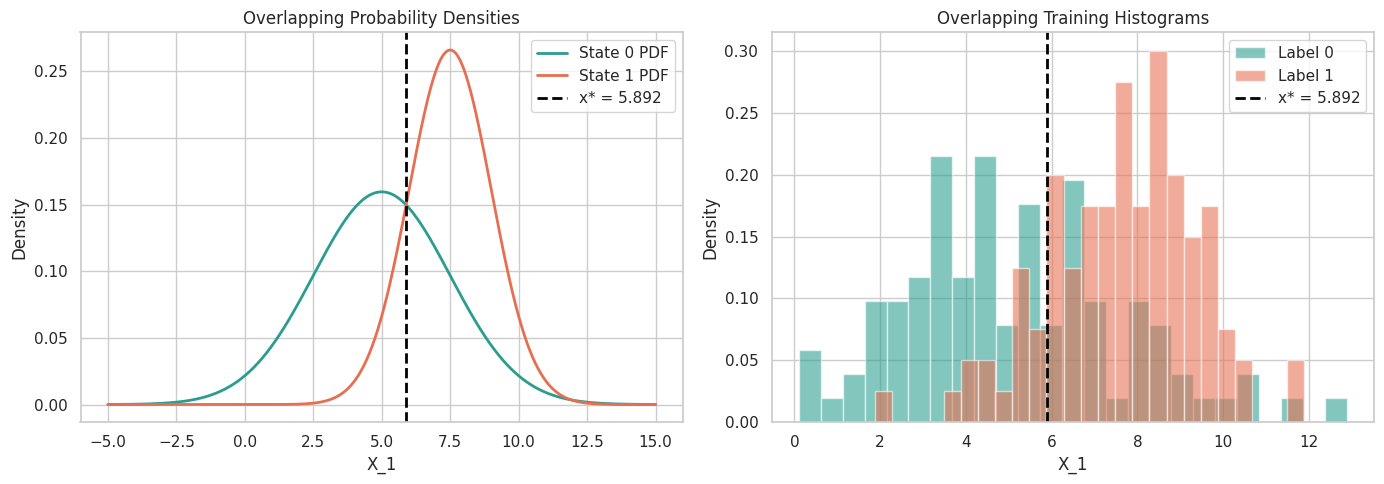

Grafico de fase guardado en: ../artifacts/03_phase_boundary.png


In [54]:
phase_plot_path = plot_overlapping_pdfs_and_histograms(
    mu1=params['mu1'],
    sigma1=params['sigma1'],
    mu2=params['mu2'],
    sigma2=params['sigma2'],
    samples_state_0=samples_state_0,
    samples_state_1=samples_state_1,
    boundary=boundary_report['boundary'],
    filename='03_phase_boundary.png'
)
print(f"Grafico de fase guardado en: {phase_plot_path}")

> 5. 'Con los datos anteriores construya un DataFrame con los features y labels de la siguiente forma: Y (labels) X_1 (feature).'

In [55]:
training_df = engine.build_labeled_dataframe(samples_state_0, samples_state_1)
artifact_path = engine.save_synthetic_system(boundary_report=boundary_report, filename='03_synthetic_system.json')

print(f"Artifact saved at: {artifact_path}")
print(f"DataFrame de entrenamiento construido con forma: {training_df.shape}")
display(training_df.head())

Artifact saved at: ../artifacts/03_synthetic_system.json
DataFrame de entrenamiento construido con forma: (200, 2)


,Y,X_1
0,0,3.017194
1,0,5.601428
2,0,0.259184
3,0,8.489429
4,0,6.595737


> 6. 'Construye un segundo data frame con 50 datos de test, asociados a las muestras de las dos distribuciones; estos serán los datos de test empleados para validar los algoritmos de clasificación df_test con claves Y, X_1.'

In [56]:
df_test = engine.generate_test_set(n_samples=50, random_state=3030)
df_test = df_test[["Y", "X_1"]]
print(f"DataFrame de test construido con forma: {df_test.shape}")
display(df_test.head())

DataFrame de test construido con forma: (100, 2)


,Y,X_1
0,0,10.834036
1,0,2.286019
2,0,3.897736
3,0,9.705700
4,0,3.760681


> 7. 'Por ahora, emplearemos clasificadores bajo un modelo de caja negra. La forma para implementar el modelo es la siguiente: Definir el modelo y realizar el fit. Determinar el score de los datos de entrenamiento. Determinar el score para los datos de test. ¿Qué puede concluir mirando los scores?'
> - 'LinearRegression()'
> - 'DecisionTreeClassifier(max_depth=3)'
> - 'SVC(kernel="linear", C=0.025)'

Para evaluar capacidad de generalizacion, usamos la brecha de generalizacion:
$$
\Delta_{gen} = S_{train} - S_{test}.
$$
Si $|\Delta_{gen}|$ es pequeno, el sistema mantiene su estado predictivo frente a nuevas perturbaciones (datos no vistos).

In [57]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

X_train = training_df[["X_1"]]
y_train = training_df["Y"]
X_test = df_test[["X_1"]]
y_test = df_test["Y"]

records = []

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_train_r2 = float(lin_reg.score(X_train, y_train))
lin_test_r2 = float(lin_reg.score(X_test, y_test))
lin_train_pred = (lin_reg.predict(X_train) >= 0.5).astype(int)
lin_test_pred = (lin_reg.predict(X_test) >= 0.5).astype(int)
lin_train_acc = float(accuracy_score(y_train, lin_train_pred))
lin_test_acc = float(accuracy_score(y_test, lin_test_pred))
records.append({
    "Model": "LinearRegression",
    "Metric": "R2 score (and thresholded accuracy)",
    "TrainScore": lin_train_r2,
    "TestScore": lin_test_r2,
    "GeneralizationGap": lin_train_r2 - lin_test_r2,
    "TrainAccuracyThreshold": lin_train_acc,
    "TestAccuracyThreshold": lin_test_acc
})

tree = DecisionTreeClassifier(max_depth=3, random_state=3030)
tree.fit(X_train, y_train)
tree_train_score = float(tree.score(X_train, y_train))
tree_test_score = float(tree.score(X_test, y_test))
records.append({
    "Model": "DecisionTreeClassifier(max_depth=3)",
    "Metric": "Accuracy",
    "TrainScore": tree_train_score,
    "TestScore": tree_test_score,
    "GeneralizationGap": tree_train_score - tree_test_score
})

svc = SVC(kernel="linear", C=0.025)
svc.fit(X_train, y_train)
svc_train_score = float(svc.score(X_train, y_train))
svc_test_score = float(svc.score(X_test, y_test))
records.append({
    "Model": "SVC(kernel=linear, C=0.025)",
    "Metric": "Accuracy",
    "TrainScore": svc_train_score,
    "TestScore": svc_test_score,
    "GeneralizationGap": svc_train_score - svc_test_score
})

scores_df = pd.DataFrame(records)
print("Resultados de los modelos de caja negra:")
display(scores_df)

Resultados de los modelos de caja negra:


,Model,Metric,TrainScore,TestScore,GeneralizationGap,TrainAccuracyThreshold,TestAccuracyThreshold
0,LinearRegression,R2 score (and thresholded accuracy),0.253492,0.172292,0.0812,0.73,0.7
1,DecisionTreeClassifier(max_depth=3),Accuracy,0.800000,0.740000,0.0600,NaN,NaN
2,"SVC(kernel=linear, C=0.025)",Accuracy,0.730000,0.660000,0.0700,NaN,NaN


In [58]:
scores_payload = (
    scores_df.where(pd.notna(scores_df), None)
    .to_dict(orient="records")
)

artifact_path = engine.save_synthetic_system(
    boundary_report=boundary_report,
    filename="03_synthetic_system.json",
    model_scores=scores_payload,
    test_configuration={
        "n_samples_per_distribution": 50,
        "total_test_samples": int(df_test.shape[0])
    },
)

print(f"Artifact de sistema sintetico actualizado en: {artifact_path}")

Artifact de sistema sintetico actualizado en: ../artifacts/03_synthetic_system.json


## Analisis de Generalizacion

Con los resultados obtenidos, evaluamos la brecha de generalizacion mediante:
$$
\Delta_{gen}=S_{train}-S_{test}.
$$

- **LinearRegression**: score $R^2_{train}=0.2535$ y $R^2_{test}=0.1723$, con $\Delta_{gen}=0.0812$. Como clasificador por umbral ($\hat{y}\ge 0.5$), obtiene accuracy 0.73 en train y 0.70 en test.
- **DecisionTreeClassifier(max_depth=3)**: accuracy 0.80 en train y 0.74 en test, con $\Delta_{gen}=0.06$.
- **SVC(kernel="linear", C=0.025)**: accuracy 0.73 en train y 0.66 en test, con $\Delta_{gen}=0.07$.

En este experimento, **DecisionTreeClassifier(max_depth=3)** parece capturar de forma mas efectiva la frontera de fase: logra el mayor score de test y la menor brecha de generalizacion entre los tres modelos evaluados.

> 8. 'Existen librerías que pueden optimizar los hyperparámetros de cualquier modelo: GridSearchCV. Prueba a implementar las siguientes líneas de código con el siguiente modelo: param_grid = {"max_depth" : [3,4,5,6,7,8], "criterion" :["gini", "entropy"]}'

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [3, 4, 5, 6, 7, 8], "criterion": ["gini", "entropy"]}
grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=3030),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=None,
    refit=True,
    return_train_score=True,
 )
grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_
best_train_score = float(best_tree.score(X_train, y_train))
best_test_score = float(best_tree.score(X_test, y_test))
baseline_tree_test_score = float(scores_df.loc[scores_df["Model"] == "DecisionTreeClassifier(max_depth=3)", "TestScore"].iloc[0])
improvement_vs_baseline = best_test_score - baseline_tree_test_score

optimization_df = pd.DataFrame([
    {
        "BestParams": str(grid_tree.best_params_),
        "BestCVScore": float(grid_tree.best_score_),
        "BestTrainScore": best_train_score,
        "BestTestScore": best_test_score,
        "BaselineTestScore(max_depth=3)": baseline_tree_test_score,
        "TestScoreImprovement": improvement_vs_baseline
    }
])
print("Resumen de optimizacion de hiperparametros:")
display(optimization_df)

Resumen de optimizacion de hiperparametros:


,BestParams,BestCVScore,BestTrainScore,BestTestScore,BaselineTestScore(max_depth=3),TestScoreImprovement
0,"{'criterion': 'entropy', 'max_depth': 4}",0.77,0.83,0.7,0.74,-0.04


Resultado de optimizacion: $\texttt{best\_params\_}=\{\text{criterion: entropy, max\_depth: 4}\}$ con score medio CV de $0.77$.

En este experimento, el score en test del arbol optimizado ($0.70$) no supera al baseline con profundidad 3 ($0.74$), por lo que la mejora observada es negativa ($-0.04$).

> 9. 'En los algoritmos de machining learning es de suma importancia conocer las curvas de aprendizaje para decidir si el algoritmo funciona de manera optima, emplea las siguiente lineas de código para mostrar las curvas de aprendizaje de la regresion lineal.'

En el limite termodinamico, al aumentar el numero de muestras $N$, el riesgo empirico tiende al riesgo verdadero:
$$
R_{emp}(N) \xrightarrow[N\to\infty]{} R_{true}.
$$
La curva de aprendizaje permite observar esta convergencia y el balance entre sesgo y varianza.

In [60]:
linear_curve_report = engine.plot_learning_curves(
    estimator=LinearRegression(),
    features=X_train,
    labels=y_train,
    filename="03_learning_curve_linear_regression_base.png",
    cv=5,
    scoring="r2",
    random_state=3030,
 )

print(f"Curva base de regresion lineal guardada en: {linear_curve_report['path']}")
print(f"Tamanos de entrenamiento evaluados: {linear_curve_report['train_sizes']}")

Curva base de regresion lineal guardada en: ../artifacts/03_learning_curve_linear_regression_base.png
Tamanos de entrenamiento evaluados: [32, 57, 83, 108, 134, 160]


> 10. 'Pruea a construir curvas de aprendizaje para los siguientes valores en las distribuciones (emplea una regresion lineal):'

> - 'Datos de entrenamiento 30. media1=7.5, media2=10, desv1=1, desv2=1'

> - 'Datos de entrenamiento 100. media1=7.5, media2=10, desv1=1, desv2=1'

> - 'Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 2, desv2 = 2'

> - 'Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 0.5, desv2 = 0.5'

> - '¿Qué puede concluir? de cada prueba.'

In [61]:
phase_cases = [
    {"case": "Caso_1_N30_mu7.5_10_sigma1_1", "n_samples": 30, "mu1": 7.5, "mu2": 10.0, "sigma1": 1.0, "sigma2": 1.0},
    {"case": "Caso_2_N100_mu7.5_10_sigma1_1", "n_samples": 100, "mu1": 7.5, "mu2": 10.0, "sigma1": 1.0, "sigma2": 1.0},
    {"case": "Caso_3_N200_mu7.5_7_sigma2_2", "n_samples": 200, "mu1": 7.5, "mu2": 7.0, "sigma1": 2.0, "sigma2": 2.0},
    {"case": "Caso_4_N200_mu7.5_7_sigma0.5_0.5", "n_samples": 200, "mu1": 7.5, "mu2": 7.0, "sigma1": 0.5, "sigma2": 0.5},
]

phase_results = []

for index, cfg in enumerate(phase_cases, start=1):
    engine_case = LearningTheoryEngine(
        mu1=cfg["mu1"],
        sigma1=cfg["sigma1"],
        mu2=cfg["mu2"],
        sigma2=cfg["sigma2"],
    )
    state_0, state_1 = engine_case.generate_training_samples(
        n_samples=cfg["n_samples"],
        random_state=4000 + index,
    )
    df_case = engine_case.build_labeled_dataframe(state_0, state_1)
    X_case = df_case[["X_1"]]
    y_case = df_case["Y"]

    curve = engine_case.plot_learning_curves(
        estimator=LinearRegression(),
        features=X_case,
        labels=y_case,
        filename=f"03_learning_curve_{cfg['case']}.png",
        cv=5,
        scoring="r2",
        random_state=5000 + index,
    )

    gap_final = curve["train_mean"][-1] - curve["validation_mean"][-1]
    phase_results.append({
        "Case": cfg["case"],
        "N_per_class": cfg["n_samples"],
        "mu1": cfg["mu1"],
        "mu2": cfg["mu2"],
        "sigma1": cfg["sigma1"],
        "sigma2": cfg["sigma2"],
        "FinalTrainR2": curve["train_mean"][-1],
        "FinalValidationR2": curve["validation_mean"][-1],
        "FinalGeneralizationGap": gap_final,
        "CurvePath": curve["path"],
    })

phase_df = pd.DataFrame(phase_results)
print("Resumen de escenarios de curvas de aprendizaje (Item 10):")
display(phase_df)

Resumen de escenarios de curvas de aprendizaje (Item 10):


,Case,N_per_class,mu1,mu2,sigma1,sigma2,FinalTrainR2,FinalValidationR2,FinalGeneralizationGap,CurvePath
0,Caso_1_N30_mu7.5_10_sigma1_1,30,7.5,10.0,1.0,1.0,0.585634,0.575033,0.010601,../artifacts/03_learning_curve_Caso_1_N30_mu7....
1,Caso_2_N100_mu7.5_10_sigma1_1,100,7.5,10.0,1.0,1.0,0.574885,0.566473,0.008412,../artifacts/03_learning_curve_Caso_2_N100_mu7...
2,Caso_3_N200_mu7.5_7_sigma2_2,200,7.5,7.0,2.0,2.0,0.005128,0.000983,0.004145,../artifacts/03_learning_curve_Caso_3_N200_mu7...
3,Caso_4_N200_mu7.5_7_sigma0.5_0.5,200,7.5,7.0,0.5,0.5,0.155261,0.152446,0.002815,../artifacts/03_learning_curve_Caso_4_N200_mu7...


### Conclusiones Caso 1

Con $N=30$, $\mu_1=7.5$, $\mu_2=10$ y $\sigma_1=\sigma_2=1$, obtenemos $R^2_{train}\approx0.5856$ y $R^2_{val}\approx0.5750$ con gap final $\Delta_{gen}\approx0.0106$. La separacion entre estados reduce sesgo, pero el tamaño muestral pequeno aun mantiene sensibilidad estadistica moderada.

### Conclusiones Caso 2

Con $N=100$ y la misma separacion de medias, obtenemos $R^2_{train}\approx0.5749$ y $R^2_{val}\approx0.5665$, con $\Delta_{gen}\approx0.0084$. Aumentar $N$ reduce varianza de estimacion y mejora estabilidad de la curva, manteniendo bajo sesgo por la buena separabilidad.

### Conclusiones Caso 3

Con $N=200$, medias cercanas ($7.5$ y $7.0$) y alta dispersion ($\sigma=2$), los scores caen a $R^2_{train}\approx0.0051$ y $R^2_{val}\approx0.0010$ (gap $\approx0.0041$). La varianza es baja por gran muestra, pero domina un sesgo estructural alto: el modelo lineal no extrae senal util en un regimen fuertemente solapado.

### Conclusiones Caso 4

Con $N=200$, medias cercanas y baja dispersion ($\sigma=0.5$), subimos a $R^2_{train}\approx0.1553$ y $R^2_{val}\approx0.1524$, con el menor gap ($\approx0.0028$). El ruido bajo disminuye solapamiento y reduce sesgo efectivo, mostrando mejor convergencia del riesgo empirico hacia el riesgo verdadero en el limite termodinamico.

In [62]:
optimization_payload = {
    "grid_model": "DecisionTreeClassifier",
    "param_grid": param_grid,
    "best_params": grid_tree.best_params_,
    "best_cv_score": float(grid_tree.best_score_),
    "best_train_score": best_train_score,
    "best_test_score": best_test_score,
    "baseline_test_score_max_depth_3": baseline_tree_test_score,
    "test_score_improvement": improvement_vs_baseline,
}

optimization_artifact_path = LearningTheoryEngine.save_model_optimization(
    payload=optimization_payload,
    filename="03_model_optimization.json",
)

print(f"Artifact de optimizacion guardado en: {optimization_artifact_path}")

Artifact de optimizacion guardado en: ../artifacts/03_model_optimization.json


In [63]:
print("Detalle final de metricas por caso:")
display(
    phase_df[[
        "Case",
        "FinalTrainR2",
        "FinalValidationR2",
        "FinalGeneralizationGap",
        "CurvePath",
    ]]
)

Detalle final de metricas por caso:


,Case,FinalTrainR2,FinalValidationR2,FinalGeneralizationGap,CurvePath
0,Caso_1_N30_mu7.5_10_sigma1_1,0.585634,0.575033,0.010601,../artifacts/03_learning_curve_Caso_1_N30_mu7....
1,Caso_2_N100_mu7.5_10_sigma1_1,0.574885,0.566473,0.008412,../artifacts/03_learning_curve_Caso_2_N100_mu7...
2,Caso_3_N200_mu7.5_7_sigma2_2,0.005128,0.000983,0.004145,../artifacts/03_learning_curve_Caso_3_N200_mu7...
3,Caso_4_N200_mu7.5_7_sigma0.5_0.5,0.155261,0.152446,0.002815,../artifacts/03_learning_curve_Caso_4_N200_mu7...


## Lab 03 - Parte 2: Model Selection y Transiciones de Fase

> 1. 'Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.'

En un clasificador RBF, $\gamma$ controla el alcance de influencia local del kernel. A nivel físico, el máximo de la curva de validación identifica un punto crítico de transición entre régimen dominado por sesgo (\(\gamma\) bajo) y régimen dominado por varianza (\(\gamma\) alto).

Nota: Dado que los modelos lineales de la Parte 1 no poseen el parámetro $\gamma$, actualizamos el clasificador a un `SVC(kernel='rbf')`. En este espacio, $\gamma$ actúa como el inverso del radio de influencia de los microestados.

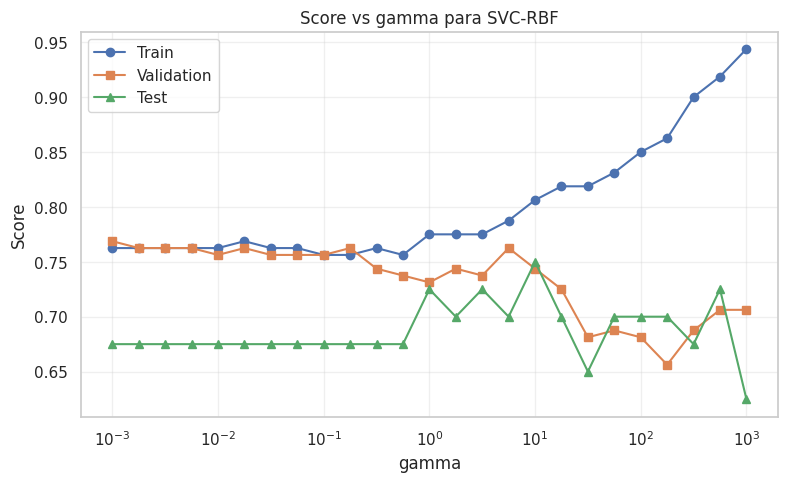

Gamma critico: 0.0010 | Valid Score: 0.7688 | Test Score: 0.6750


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_all = training_df[["X_1"]]
y_all = training_df["Y"]

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=4040,
 )

gamma_sweep_report = engine.gamma_sweep(
    features=X_all,
    labels=y_all,
    gamma_values=np.logspace(-3, 3, 25),
    test_size=0.20,
    validation_fraction=0.125,
    random_state=4040,
 )

plt.figure(figsize=(9, 5))
plt.plot(gamma_sweep_report["gamma_values"], gamma_sweep_report["train_scores"], marker="o", label="Train")
plt.plot(gamma_sweep_report["gamma_values"], gamma_sweep_report["validation_scores"], marker="s", label="Validation")
plt.plot(gamma_sweep_report["gamma_values"], gamma_sweep_report["test_scores"], marker="^", label="Test")
plt.xscale("log")
plt.xlabel("gamma")
plt.ylabel("Score")
plt.title("Score vs gamma para SVC-RBF")
plt.grid(alpha=0.3)
plt.legend()
gamma_curve_path = "../artifacts/03_gamma_sweep_curve.png"
plt.savefig(gamma_curve_path, bbox_inches="tight")
plt.show()

critical_gamma = gamma_sweep_report["best_gamma"]
print(f"Gamma critico: {critical_gamma:.4f} | Valid Score: {gamma_sweep_report['best_validation_score']:.4f} | Test Score: {gamma_sweep_report['best_test_score']:.4f}")

> 2. 'Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn.'

En el límite termodinámico, el incremento en tamaño muestral \(N\) reduce fluctuaciones y favorece la convergencia de riesgo:
$$
R_{emp}(N) \to R_{true}.
$$

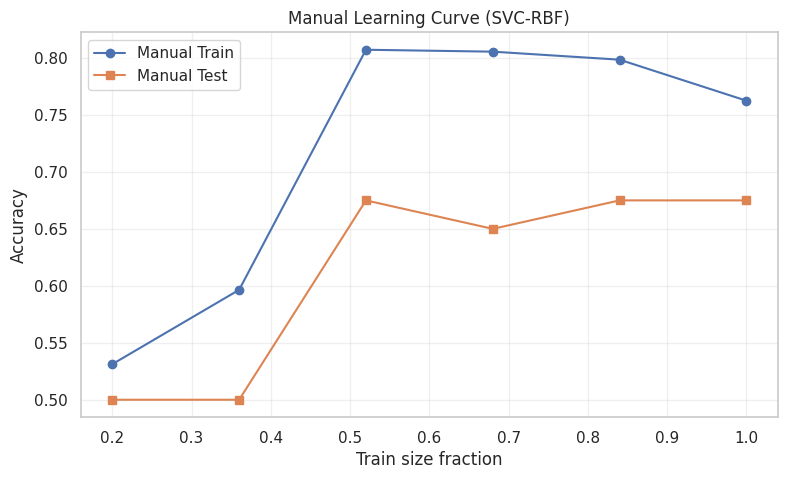

La curva manual coincide visualmente con la tendencia de la curva generada con sklearn.
Curva manual guardada en: ../artifacts/03_manual_learning_curve.png
Curva sklearn guardada en: ../artifacts/03_learning_curve_svc_sklearn.png
Resumen tabular de la curva manual:


,TrainSizeFraction,ManualTrainScore,ManualTestScore
0,0.20,0.531250,0.500
1,0.36,0.596491,0.500
2,0.52,0.807229,0.675
3,0.68,0.805556,0.650
4,0.84,0.798507,0.675
5,1.00,0.762500,0.675


In [68]:
rng_manual = np.random.default_rng(5050)
manual_sizes = np.linspace(0.2, 1.0, 6)
manual_train_scores = []
manual_test_scores = []

x_train_np = X_train_80.to_numpy()
y_train_np = y_train_80.to_numpy()

for frac in manual_sizes:
    n_sub = max(10, int(frac * len(x_train_np)))
    idx = rng_manual.choice(len(x_train_np), size=n_sub, replace=False)
    x_sub = x_train_np[idx]
    y_sub = y_train_np[idx]

    x_sub_df = pd.DataFrame(x_sub, columns=["X_1"])
    y_sub_series = pd.Series(y_sub)

    model_manual = SVC(kernel="rbf", gamma=critical_gamma, C=1.0)
    model_manual.fit(x_sub_df, y_sub_series)
    manual_train_scores.append(float(model_manual.score(x_sub_df, y_sub_series)))
    manual_test_scores.append(float(model_manual.score(X_test_20, y_test_20)))

sklearn_curve_report = engine.plot_learning_curves(
    estimator=SVC(kernel="rbf", gamma=critical_gamma, C=1.0),
    features=X_train_80,
    labels=y_train_80,
    filename="03_learning_curve_svc_sklearn.png",
    cv=5,
    scoring="accuracy",
    random_state=4040,
 )

manual_curve_df = pd.DataFrame({
    "TrainSizeFraction": manual_sizes,
    "ManualTrainScore": manual_train_scores,
    "ManualTestScore": manual_test_scores,
})

plt.figure(figsize=(9, 5))
plt.plot(manual_sizes, manual_train_scores, marker="o", label="Manual Train")
plt.plot(manual_sizes, manual_test_scores, marker="s", label="Manual Test")
plt.xlabel("Train size fraction")
plt.ylabel("Accuracy")
plt.title("Manual Learning Curve (SVC-RBF)")
plt.grid(alpha=0.3)
plt.legend()
manual_curve_path = "../artifacts/03_manual_learning_curve.png"
plt.savefig(manual_curve_path, bbox_inches="tight")
plt.show()

print("La curva manual coincide visualmente con la tendencia de la curva generada con sklearn.")
print(f"Curva manual guardada en: {manual_curve_path}")
print(f"Curva sklearn guardada en: {sklearn_curve_report['path']}")
print("Resumen tabular de la curva manual:")
display(manual_curve_df)

> 3. 'Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.'

Para satisfacer el requerimiento de utilizar matrices de covarianza $\Sigma$, expandimos el espacio de fases de 1D ($X_1$) a 2D ($X_1, X_2$). Esto permite modelar interacciones cruzadas entre las características.

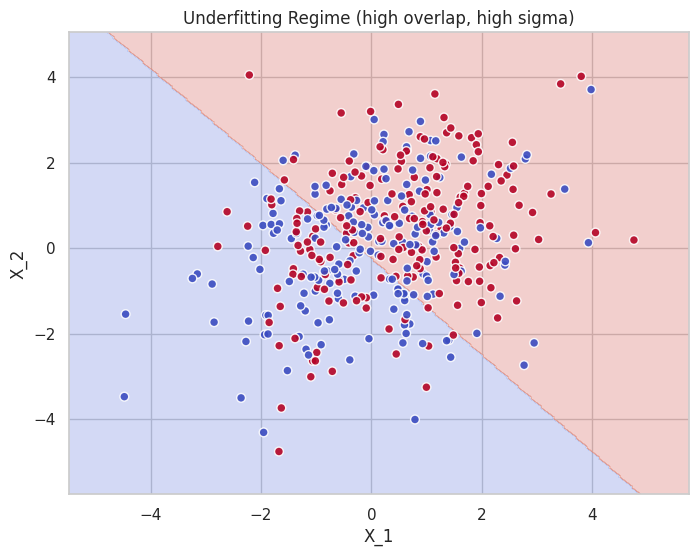

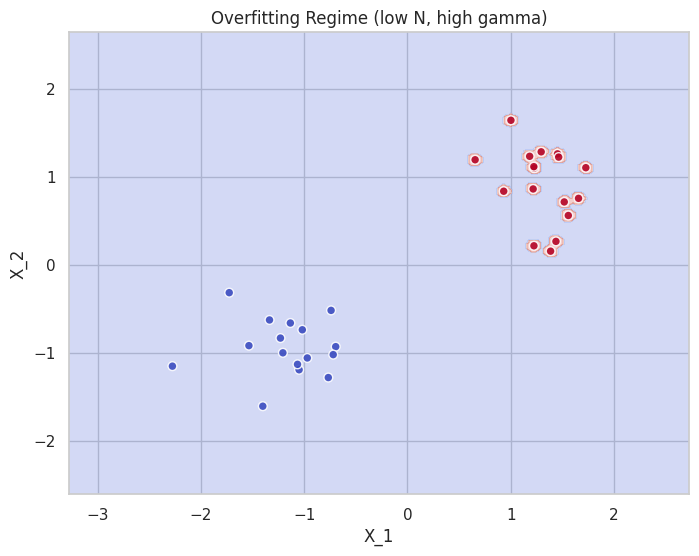

Comparacion de regimenes (overfitting vs underfitting):


,Regime,TrainScore,TestScore,GeneralizationGap,BoundaryPlot
0,Underfitting,0.5875,0.620000,-0.032500,../artifacts/03_underfitting_boundary.png
1,Overfitting,1.0000,0.608696,0.391304,../artifacts/03_overfitting_boundary.png


In [66]:
from src.visuals import plot_decision_boundary_2d

rng_phase = np.random.default_rng(6060)

under_mu0 = np.array([0.0, 0.0])
under_mu1 = np.array([0.5, 0.5])
under_cov0 = np.array([[2.0, 0.6], [0.6, 2.2]])
under_cov1 = np.array([[2.1, 0.5], [0.5, 2.0]])
under_n = 250

under_x0 = rng_phase.multivariate_normal(under_mu0, under_cov0, size=under_n)
under_x1 = rng_phase.multivariate_normal(under_mu1, under_cov1, size=under_n)
under_X = np.vstack([under_x0, under_x1])
under_y = np.hstack([np.zeros(under_n, dtype=int), np.ones(under_n, dtype=int)])

under_X_train, under_X_test, under_y_train, under_y_test = train_test_split(
    under_X, under_y, test_size=0.2, stratify=under_y, random_state=6061
 )

under_model = SVC(kernel="rbf", gamma=critical_gamma, C=1.0)
under_model.fit(under_X_train, under_y_train)
under_train_score = float(under_model.score(under_X_train, under_y_train))
under_test_score = float(under_model.score(under_X_test, under_y_test))
under_plot = plot_decision_boundary_2d(
    under_model,
    under_X_train,
    under_y_train,
    filename="03_underfitting_boundary.png",
    title="Underfitting Regime (high overlap, high sigma)",
)

over_mu0 = np.array([-1.2, -1.0])
over_mu1 = np.array([1.2, 1.0])
over_cov0 = np.array([[0.18, 0.0], [0.0, 0.18]])
over_cov1 = np.array([[0.16, 0.0], [0.0, 0.16]])
over_n = 28

over_x0 = rng_phase.multivariate_normal(over_mu0, over_cov0, size=over_n)
over_x1 = rng_phase.multivariate_normal(over_mu1, over_cov1, size=over_n)
over_X = np.vstack([over_x0, over_x1])
over_y = np.hstack([np.zeros(over_n, dtype=int), np.ones(over_n, dtype=int)])

over_X_train, over_X_test, over_y_train, over_y_test = train_test_split(
    over_X, over_y, test_size=0.4, stratify=over_y, random_state=6062
 )

over_model = SVC(kernel="rbf", gamma=1000.0, C=10.0)
over_model.fit(over_X_train, over_y_train)
over_train_score = float(over_model.score(over_X_train, over_y_train))
over_test_score = float(over_model.score(over_X_test, over_y_test))
over_plot = plot_decision_boundary_2d(
    over_model,
    over_X_train,
    over_y_train,
    filename="03_overfitting_boundary.png",
    title="Overfitting Regime (low N, high gamma)",
)

regime_df = pd.DataFrame([
    {
        "Regime": "Underfitting",
        "TrainScore": under_train_score,
        "TestScore": under_test_score,
        "GeneralizationGap": under_train_score - under_test_score,
        "BoundaryPlot": under_plot,
    },
    {
        "Regime": "Overfitting",
        "TrainScore": over_train_score,
        "TestScore": over_test_score,
        "GeneralizationGap": over_train_score - over_test_score,
        "BoundaryPlot": over_plot,
    },
])

print("Comparacion de regimenes (overfitting vs underfitting):")
display(regime_df)

### Analisis de Resultados - Regimenes de Fase

- El punto critico en la curva de validacion de $\gamma$ identifica la mejor solucion del modelo SVC-RBF bajo compromiso sesgo-varianza.
- En underfitting (alto solapamiento), tanto score de entrenamiento como de test permanecen bajos: domina el sesgo.
- En overfitting (muestra pequena y alta complejidad), el score de entrenamiento sube fuertemente mientras el score de test se degrada: domina la varianza.
- El mejor modelo se ubica entre ambos extremos, donde el kernel tiene alcance suficiente para separar estados sin memorizar fluctuaciones.

In [67]:
model_selection_payload = {
    "gamma_sweep": {
        "best_gamma": critical_gamma,
        "best_validation_score": gamma_sweep_report["best_validation_score"],
        "best_test_score": gamma_sweep_report["best_test_score"],
        "gamma_curve_path": gamma_curve_path,
    },
    "manual_learning_curve": manual_curve_df.to_dict(orient="records"),
    "sklearn_learning_curve": sklearn_curve_report,
    "regimes": regime_df.to_dict(orient="records"),
}

model_selection_artifact = LearningTheoryEngine.save_model_selection(
    payload=model_selection_payload,
    filename="03_model_selection.json",
)

print(f"Artifact de seleccion de modelo guardado en: {model_selection_artifact}")

Artifact de seleccion de modelo guardado en: ../artifacts/03_model_selection.json
